notebook specifically about EDA + understanding the final dataset.

04_EDA.ipynb
│
├── 1. Load processed dataset
├── 2. Basic inspection
│     ├── shape
│     ├── info
│     ├── describe
│     └── unique values
│
├── 3. Univariate Analysis
│     ├── distributions
│     └── boxplots / outliers
│
├── 4. Bivariate Analysis
│     ├── correlations
│     └── important relationships
│
├── 5. Multivariate Analysis
│     └── correlation heatmap
│
└── 6. EDA Findings
      └── what we learned / features to consider

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/india_cost_quality_merged.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (116, 14)


,City,Average Rent (INR/month),Food Cost (INR/month),Internet Speed (Mbps),Healthcare Rating,Safety Score,Happiness Index,months_covered,cost_one_person_inr,rent_one_person_inr,monthly_salary_after_tax_inr,income_after_rent_inr,rent_difference_inr,rent_difference_percent
0,Mumbai,34896,6196,94.48,6.2,2.7,5.3,0.3,61943.98,35233.38,19505.76,-15727.62,337.38,0.966816
1,Delhi,26424,4487,130.26,6.1,2.6,5.6,0.5,42965.40,16694.12,20296.54,3602.42,-9729.88,36.822131
2,Bengaluru,26667,6936,81.36,8.7,6.7,7.5,0.6,40680.94,19417.90,27325.64,7907.74,-7249.10,27.183785
3,Hyderabad,25785,6375,108.84,7.8,7.7,6.3,0.6,41295.99,14936.85,25480.50,10543.66,-10848.15,42.071553
4,Ahmedabad,20881,3632,130.80,5.5,7.9,4.3,0.7,38835.80,13970.34,27237.78,13267.43,-6910.66,33.095446


In [2]:
df.shape

(116, 14)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   City                          116 non-null    str    
 1   Average Rent (INR/month)      116 non-null    int64  
 2   Food Cost (INR/month)         116 non-null    int64  
 3   Internet Speed (Mbps)         116 non-null    float64
 4   Healthcare Rating             116 non-null    float64
 5   Safety Score                  116 non-null    float64
 6   Happiness Index               116 non-null    float64
 7   months_covered                116 non-null    float64
 8   cost_one_person_inr           116 non-null    float64
 9   rent_one_person_inr           116 non-null    float64
 10  monthly_salary_after_tax_inr  116 non-null    float64
 11  income_after_rent_inr         116 non-null    float64
 12  rent_difference_inr           116 non-null    float64
 13  rent_difference_

In [3]:
df.describe()

,Average Rent (INR/month),Food Cost (INR/month),Internet Speed (Mbps),Healthcare Rating,Safety Score,Happiness Index,months_covered,cost_one_person_inr,rent_one_person_inr,monthly_salary_after_tax_inr,income_after_rent_inr,rent_difference_inr,rent_difference_percent
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,8483.543103,5503.163793,85.833190,6.424138,5.323276,6.338793,1.100862,31643.086466,10866.252069,32318.729397,21452.477500,2382.708966,62.529602
std,5685.971878,1416.506799,33.809591,1.433428,1.992916,1.311605,0.357891,7944.760601,5173.845961,9045.532879,10398.731685,5875.877700,69.778630
min,4009.000000,3021.000000,20.350000,4.000000,2.100000,4.100000,0.300000,22053.810000,5298.190000,17484.900000,-16430.530000,-15176.470000,0.275110
25%,5498.500000,4397.500000,58.640000,5.175000,3.675000,5.175000,0.900000,26315.207500,8061.507500,25722.125000,15778.142500,-50.140000,17.468612
50%,6876.000000,5439.000000,90.105000,6.350000,5.400000,6.500000,1.100000,29346.510000,9708.950000,31499.175000,21803.400000,1991.080000,37.738693
75%,8580.000000,6716.000000,110.657500,7.700000,6.950000,7.500000,1.300000,33717.737500,11378.362500,37320.147500,27336.627500,4642.207500,84.882910
max,34896.000000,7999.000000,149.460000,8.800000,8.900000,8.400000,2.100000,61943.980000,40241.620000,59747.380000,44371.220000,30544.620000,382.026553


In [4]:
df.isnull().sum()

City                            0
Average Rent (INR/month)        0
Food Cost (INR/month)           0
Internet Speed (Mbps)           0
Healthcare Rating               0
Safety Score                    0
Happiness Index                 0
months_covered                  0
cost_one_person_inr             0
rent_one_person_inr             0
monthly_salary_after_tax_inr    0
income_after_rent_inr           0
rent_difference_inr             0
rent_difference_percent         0
dtype: int64

In [5]:
numeric_cols = df.select_dtypes(include="number").columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    "Outlier Count",
    ascending=False
)

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count
11,rent_difference_inr,-50.140000,4642.20750,-7088.661250,11680.728750,13
8,rent_one_person_inr,8061.507500,11378.36250,3086.225000,16353.645000,11
0,Average Rent (INR/month),5498.500000,8580.00000,876.250000,13202.250000,11
7,cost_one_person_inr,26315.207500,33717.73750,15211.412500,44821.532500,8
12,rent_difference_percent,17.468612,84.88291,-83.652836,186.004358,8
9,monthly_salary_after_tax_inr,25722.125000,37320.14750,8325.091250,54717.181250,3
6,months_covered,0.900000,1.30000,0.300000,1.900000,2
10,income_after_rent_inr,15778.142500,27336.62750,-1559.585000,44674.355000,2
1,Food Cost (INR/month),4397.500000,6716.00000,919.750000,10193.750000,0
4,Safety Score,3.675000,6.95000,-1.237500,11.862500,0


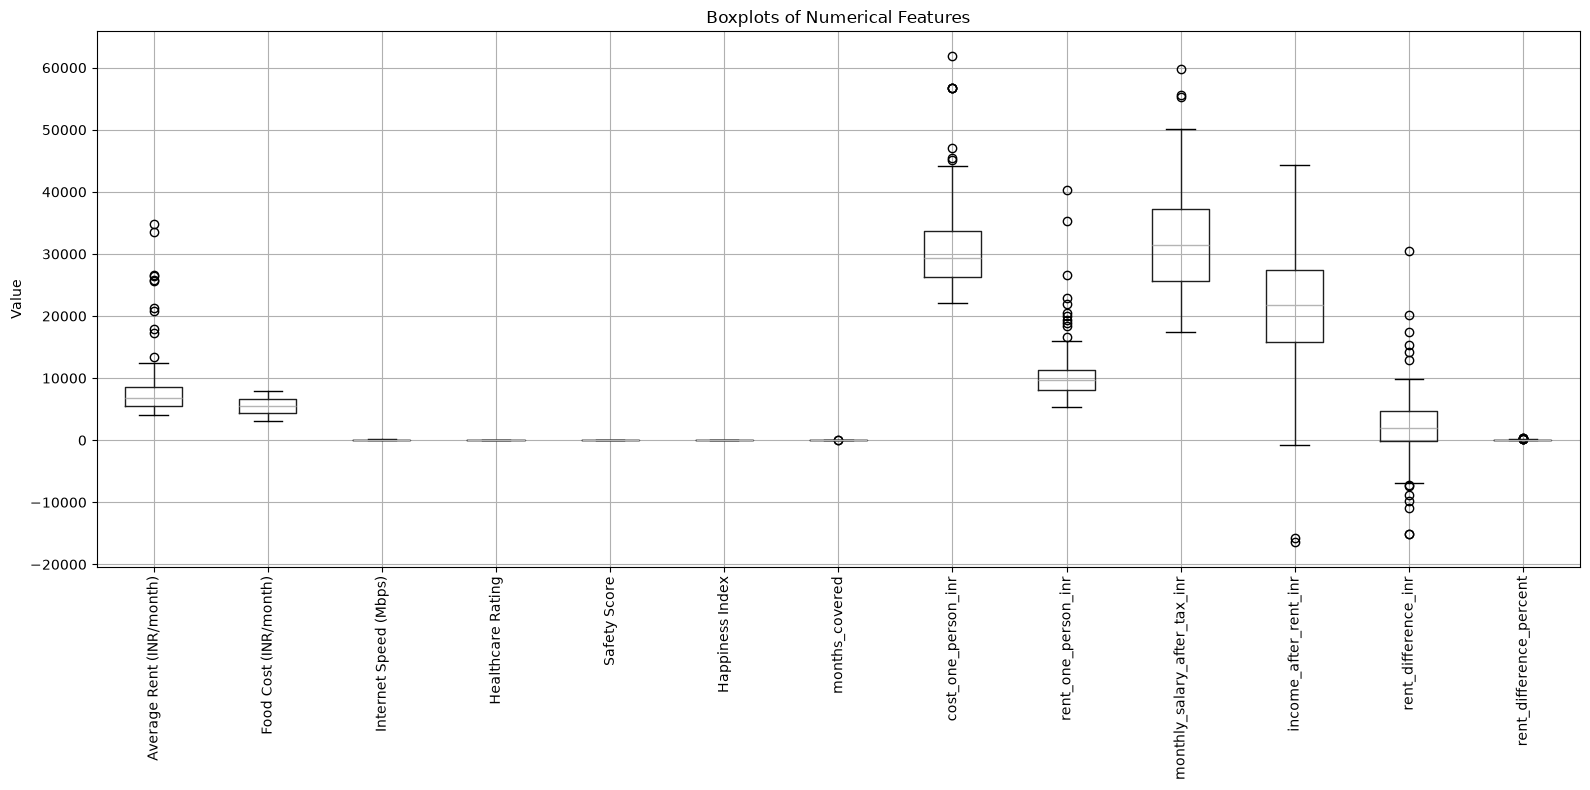

In [7]:
import os
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include="number").columns

plt.figure(figsize=(16, 8))

df[numeric_cols].boxplot(rot=90)

plt.title("Boxplots of Numerical Features")
plt.ylabel("Value")
plt.tight_layout()

os.makedirs("../visualizations/outliers", exist_ok=True)

plt.savefig("../visualizations/outliers/numerical_features_boxplot.png")
plt.show()

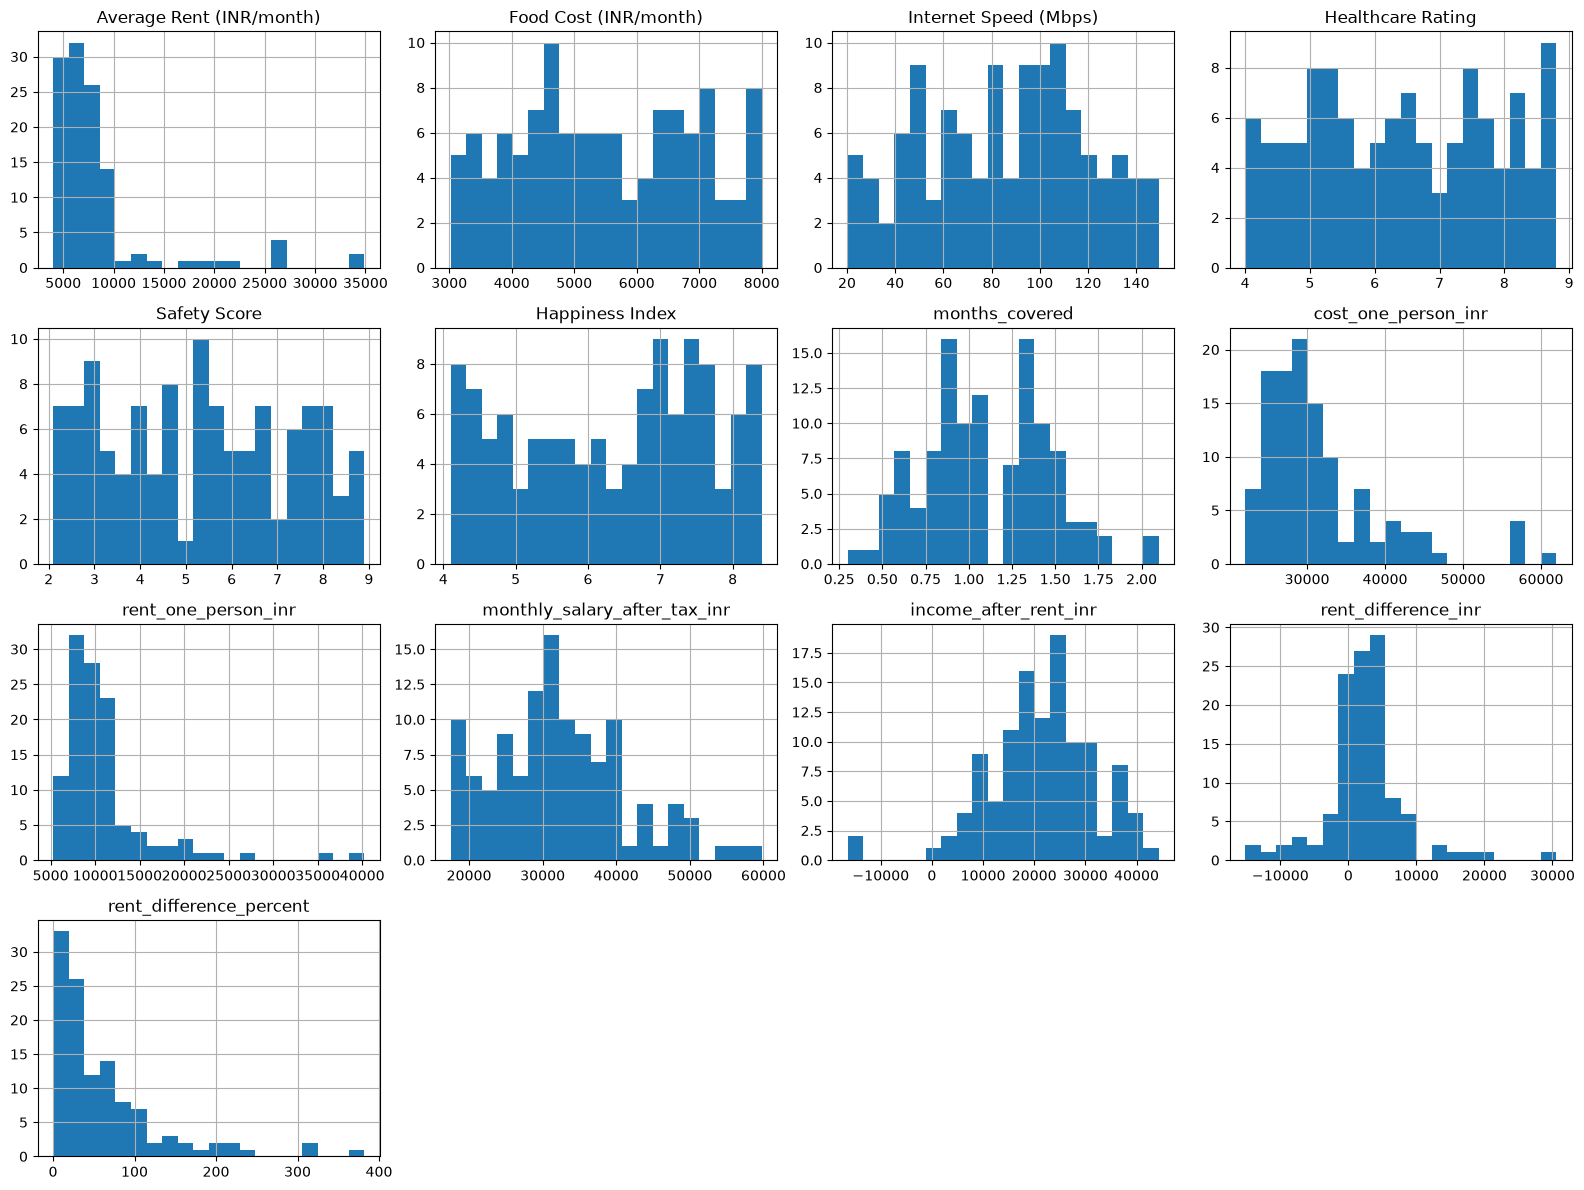

In [8]:
numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols].hist(
    figsize=(16, 12),
    bins=20
)

plt.tight_layout()
plt.savefig("../visualizations/distributions/numerical_distributions.png")
plt.show()

What this distribution plot tells us

We plotted histograms for all 13 numerical features in our final 116-city dataset.

1. Average Rent (INR/month)

Clearly right-skewed.

Most cities are around ₹4,000–₹10,000, while a few cities have much higher values (Mumbai, etc.).

➡️ This matches what we saw in the boxplot: several high-value outliers.

2. Food Cost (INR/month)

Much more evenly spread, roughly ₹3,000–₹8,000.

➡️ No major skew/outlier problem.

3. Internet Speed

Reasonably spread between ~20–150 Mbps.

➡️ No obvious extreme outliers.

4. Healthcare Rating, Safety Score, Happiness Index

These are bounded rating-type variables.

➡️ Their distributions are fairly spread out and don't show concerning extreme values.

5. months_covered

Mostly between ~0.5 and 1.5, with a few higher values.

➡️ Some mild skew/outliers, which we already detected with IQR.

6. cost_one_person_inr

Right-skewed.

Most cities are around ₹25k–₹35k, but some go beyond ₹50k–₹60k.

➡️ Consistent with the outliers we detected.

7. rent_one_person_inr

Also strongly right-skewed.

Most values are relatively low, with a few cities having very high rent.

➡️ Important feature for our project.

8. monthly_salary_after_tax_inr

Fairly spread out, but with some high-income cities.

➡️ Mild right skew.

9. income_after_rent_inr

This one is interesting.

Most cities are positive, but there are a few cities where it becomes negative.

That means:

estimated post-tax monthly salary − estimated one-person rent < 0

Those cities are potentially very expensive relative to income.

That's highly relevant to SmartShift AI.

10. rent_difference_inr

This is our derived feature:

rent_one_person_inr - Average Rent (INR/month)

It's centered mostly around positive values but has some negative and very high values.

This is not an original dataset feature; we created it during our integration/feature-engineering step.

11. rent_difference_percent

This is the most obviously right-skewed feature.

Most cities are relatively low, while a handful have extremely large percentages.

And remember our earlier finding:

We should not interpret this as a literal percentage increase in rent because the two rent columns come from different sources/definitions.

We're keeping it as a derived comparison feature, not treating it as ground truth.

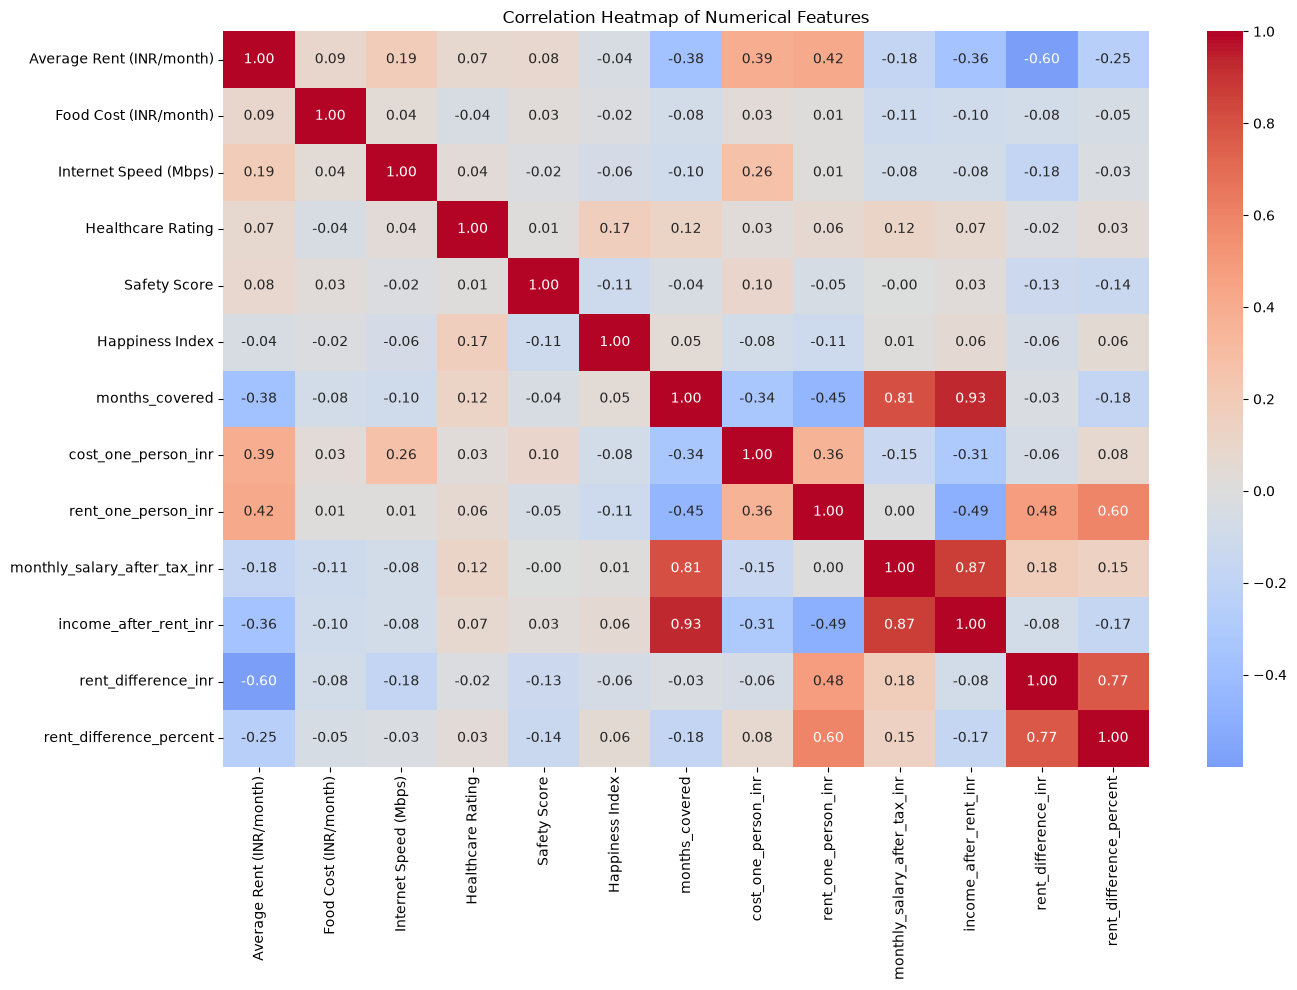

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()

plt.savefig(
    "../visualizations/correlations/numerical_correlation_heatmap.png"
)

plt.show()

In [ ]:
# We should make 3–4 targeted scatter plots, not 20 random ones.

# I'd choose:

# Plot 1

# Monthly Salary vs Income After Rent

# Because correlation = 0.87

# Plot 2

# Rent vs Income After Rent

# Because correlation = -0.49

# Plot 3

# Average Rent vs One-Person Rent

# Because correlation = 0.42

# Plot 4

# Safety Score vs Happiness Index

# Because this tests an intuitive assumption even though correlation is weak

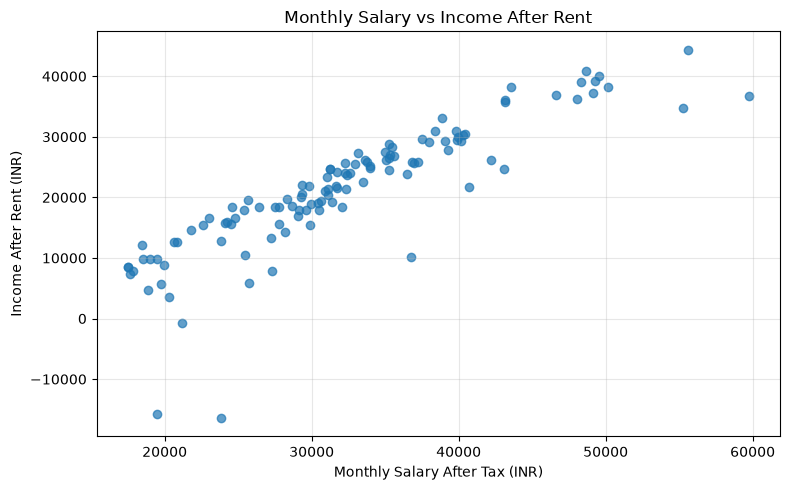

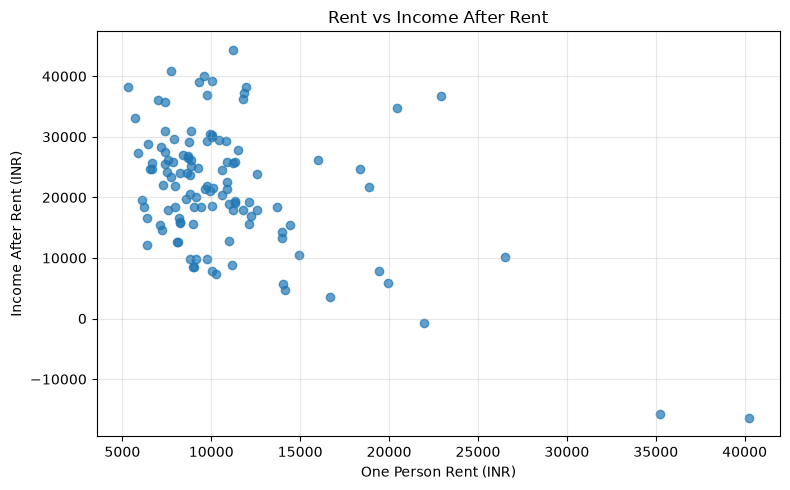

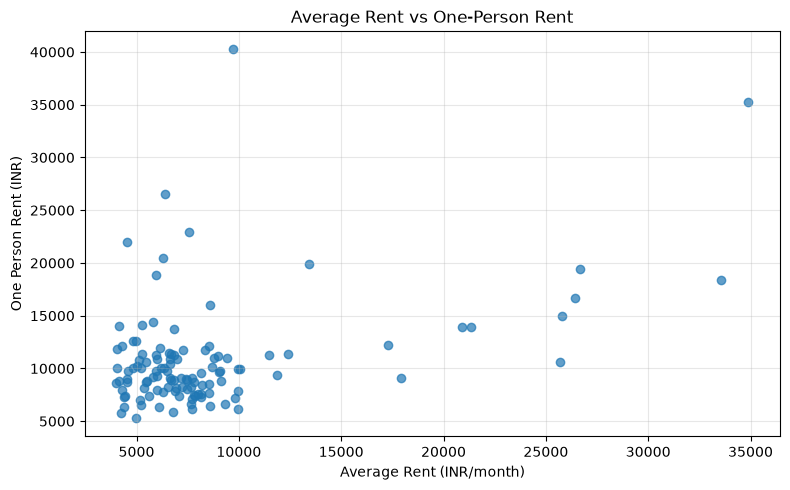

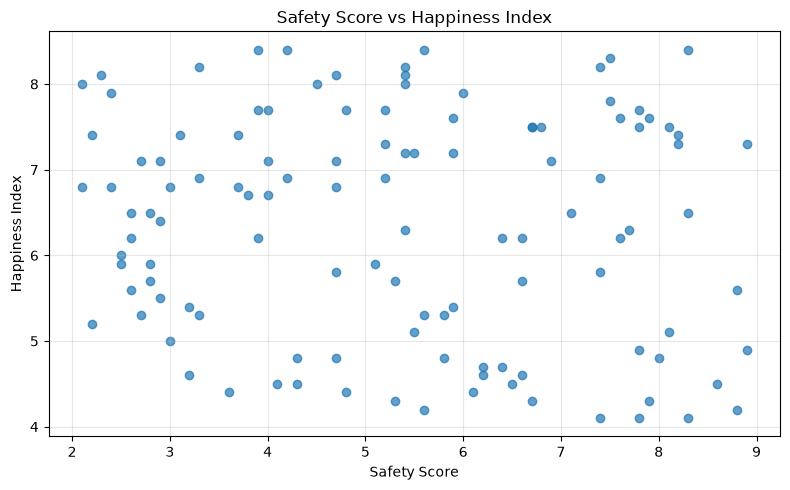

In [3]:
import matplotlib.pyplot as plt

relationships = [
    (
        "monthly_salary_after_tax_inr",
        "income_after_rent_inr",
        "Monthly Salary vs Income After Rent",
        "Monthly Salary After Tax (INR)",
        "Income After Rent (INR)",
        "salary_vs_income_after_rent.png"
    ),
    (
        "rent_one_person_inr",
        "income_after_rent_inr",
        "Rent vs Income After Rent",
        "One Person Rent (INR)",
        "Income After Rent (INR)",
        "rent_vs_income_after_rent.png"
    ),
    (
        "Average Rent (INR/month)",
        "rent_one_person_inr",
        "Average Rent vs One-Person Rent",
        "Average Rent (INR/month)",
        "One Person Rent (INR)",
        "average_rent_vs_one_person_rent.png"
    ),
    (
        "Safety Score",
        "Happiness Index",
        "Safety Score vs Happiness Index",
        "Safety Score",
        "Happiness Index",
        "safety_vs_happiness.png"
    )
]

for x, y, title, xlabel, ylabel, filename in relationships:

    plt.figure(figsize=(8, 5))

    plt.scatter(df[x], df[y], alpha=0.7)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"../visualizations/relationships/{filename}")
    plt.show()

In [6]:
df.columns

Index(['City', 'Average Rent (INR/month)', 'Food Cost (INR/month)',
       'Internet Speed (Mbps)', 'Healthcare Rating', 'Safety Score',
       'Happiness Index', 'months_covered', 'cost_one_person_inr',
       'rent_one_person_inr', 'monthly_salary_after_tax_inr',
       'income_after_rent_inr', 'rent_difference_inr',
       'rent_difference_percent'],
      dtype='str')